# CatBoost

## 1. Импорты и конфигурация

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from catboost import CatBoostRegressor, Pool

import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TASK_TYPE = 'GPU' if __import__('torch').cuda.is_available() else 'CPU'
print(f'Task type: {TASK_TYPE}')
DATA_PATH = Path('../../data/train_data_v2.csv')
TARGET = 'target'
MODEL_SAVE_PATH = Path('../../models/catboost_best.cbm')

pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Загрузка данных

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df[TARGET].describe())

Shape: (6200, 134)
count   6200.0000
mean       0.0008
std        0.0859
min       -0.1450
25%       -0.0612
50%       -0.0155
75%        0.0402
max        0.2186
Name: target, dtype: float64


## 3. Признаки

In [3]:
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center', 'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'nearest_offices_dist_m', 'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m', 'nearest_hotels_hostels_dist_m',
    'land_use_dist_m', 'city_center_dist_m', 'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m', 'count_banks_atms_300m',
    'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m',
    'count_education_300m', 'count_post_offices_300m',
    'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m',
    'count_hypermarkets_300m', 'count_markets_300m',
    'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = [
    'federal_district', 'city_size_category', 'land_use_type', 'atm_group',
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков: {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Итого признаков: 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 4. Подготовка данных

**Разбивка train / val / test = 70% / 15% / 15%**  
- Optuna и early stopping оптимизируют по **val** - модель не видит test до финального отчёта  
- Финальные метрики считаются один раз на **test**

In [4]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in DISTANCE_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col])

cat_cols = [f for f in CATEGORICAL_FEATURES if f in X.columns]
for col in cat_cols:
    X[col] = X[col].fillna('unknown').astype(str)

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')

Train : (4339, 67)  (70%)
Val   : (931, 67)  (15%)
Test  : (930, 67)  (15%)


## 5. CatBoost Pool

In [5]:
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool = Pool(X_val,   y_val,   cat_features=cat_cols)
test_pool = Pool(X_test,  y_test,  cat_features=cat_cols)
print(f'Cat features ({len(cat_cols)}): {cat_cols}')

Cat features (4): ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']


In [6]:
def report_metrics(model_name, model, X_tr, y_tr, X_te, y_te, fit_time):
    t0 = time.perf_counter()
    y_pred_train = model.predict(X_tr)
    train_pred_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    y_pred_test = model.predict(X_te)
    test_pred_time = time.perf_counter() - t0
    def _m(yt, yp):
        return {'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
                'MAE':  round(float(mean_absolute_error(yt, yp)), 4),
                'R2':   round(float(r2_score(yt, yp)), 4)}
    train_m = _m(y_tr, y_pred_train)
    test_m  = _m(y_te, y_pred_test)
    table = pd.DataFrame([
        {'Split': 'Train', **train_m, 'Fit time, s': round(fit_time, 2), 'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',  **test_m,  'Fit time, s': float('nan'),        'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')
    print(f'\n{model_name}')
    display(table.style.format(
        {'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
         'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'},
        na_rep='-'
    ))
    return {
        'Model': model_name,
        'Test RMSE': test_m['RMSE'], 'Test MAE': test_m['MAE'], 'Test R2': test_m['R2'],
        'Fit time, s': round(fit_time, 2), 'Predict time, s': round(test_pred_time, 4),
    }

## 6. Baseline CatBoost

In [7]:
t0 = time.perf_counter()
cb_baseline = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    task_type=TASK_TYPE,
    random_seed=RANDOM_STATE,
    eval_metric='RMSE',
    verbose=100,
)
cb_baseline.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)
fit_time_base = time.perf_counter() - t0

base_m = report_metrics('Baseline CatBoost', cb_baseline, X_train, y_train, X_test, y_test, fit_time_base)
rmse_base = base_m['Test RMSE']
mae_base  = base_m['Test MAE']
r2_base   = base_m['Test R2']

0:	learn: 0.0833889	test: 0.0817006	best: 0.0817006 (0)	total: 102ms	remaining: 1m 41s
100:	learn: 0.0445398	test: 0.0465875	best: 0.0465875 (100)	total: 2.04s	remaining: 18.1s
200:	learn: 0.0418886	test: 0.0459793	best: 0.0459793 (200)	total: 3.96s	remaining: 15.8s
300:	learn: 0.0399009	test: 0.0456686	best: 0.0456636 (298)	total: 5.88s	remaining: 13.7s
400:	learn: 0.0385224	test: 0.0455442	best: 0.0455420 (395)	total: 7.72s	remaining: 11.5s
500:	learn: 0.0372091	test: 0.0454896	best: 0.0454651 (489)	total: 9.54s	remaining: 9.5s
bestTest = 0.04546510491
bestIteration = 489
Shrink model to first 490 iterations.

Baseline CatBoost


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0373,0.0295,0.8130,14.01,0.0120
Test,0.0455,0.0365,0.7223,-,0.0034


## 7. Подбор гиперпараметров (Optuna, 100 trials)

In [8]:
def objective(trial):
    params = {
        'iterations':          1000,
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth':               trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count':        trial.suggest_int('border_count', 32, 128),
        'task_type':           TASK_TYPE,
        'random_seed':         RANDOM_STATE,
        'eval_metric':         'RMSE',
        'verbose':             False,
        'early_stopping_rounds': 50,
    }
    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=val_pool)
    pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, pred))

study = optuna.create_study(
    direction='minimize',
    study_name='catboost_optuna',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE (val): {study.best_value:.4f}')
print('Best params:', study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]


Best RMSE (val): 0.0447
Best params: {'learning_rate': 0.07130150795162801, 'depth': 10, 'l2_leaf_reg': 4.407671553359149, 'bagging_temperature': 0.6794975748843504, 'random_strength': 1.122281804586107, 'border_count': 83}


## 8. Финальная модель

In [9]:
best_params = dict(study.best_params)
best_params.update({
    'iterations':  2000,
    'task_type':   TASK_TYPE,
    'random_seed': RANDOM_STATE,
    'eval_metric': 'RMSE',
    'verbose':     100,
})

t0 = time.perf_counter()
cb_final = CatBoostRegressor(**best_params)
cb_final.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)
fit_time_final = time.perf_counter() - t0

final_m = report_metrics('Final CatBoost (Optuna)', cb_final, X_train, y_train, X_test, y_test, fit_time_final)
rmse_final = final_m['Test RMSE']
mae_final  = final_m['Test MAE']
r2_final   = final_m['Test R2']
print(f'Best iteration: {cb_final.best_iteration_}')

0:	learn: 0.0822441	test: 0.0806006	best: 0.0806006 (0)	total: 25.8ms	remaining: 51.5s
100:	learn: 0.0411496	test: 0.0458381	best: 0.0458304 (98)	total: 6.1s	remaining: 1m 54s
200:	learn: 0.0364345	test: 0.0453147	best: 0.0453147 (200)	total: 12.3s	remaining: 1m 49s
bestTest = 0.04524545324
bestIteration = 232
Shrink model to first 233 iterations.

Final CatBoost (Optuna)


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0358,0.0282,0.8277,17.62,0.0109
Test,0.0453,0.0362,0.7249,-,0.0043


Best iteration: 232


## 9. Финальная модель для сохранения

In [10]:
trainval_pool = Pool(X_trainval, y_trainval, cat_features=cat_cols)

best_params_save = dict(study.best_params)
best_params_save.update({
    'iterations':  cb_final.best_iteration_ + 1,
    'task_type':   TASK_TYPE,
    'random_seed': RANDOM_STATE,
    'eval_metric': 'RMSE',
    'verbose':     100,
})

cb_save = CatBoostRegressor(**best_params_save)
cb_save.fit(trainval_pool)
print(f'Trained on train+val for {cb_final.best_iteration_ + 1} iterations')

0:	learn: 0.0826721	total: 31.9ms	remaining: 7.4s
100:	learn: 0.0341074	total: 3.04s	remaining: 3.97s
200:	learn: 0.0256482	total: 5.95s	remaining: 947ms
232:	learn: 0.0234592	total: 6.88s	remaining: 0us
Trained on train+val for 233 iterations


## 10. Важность признаков

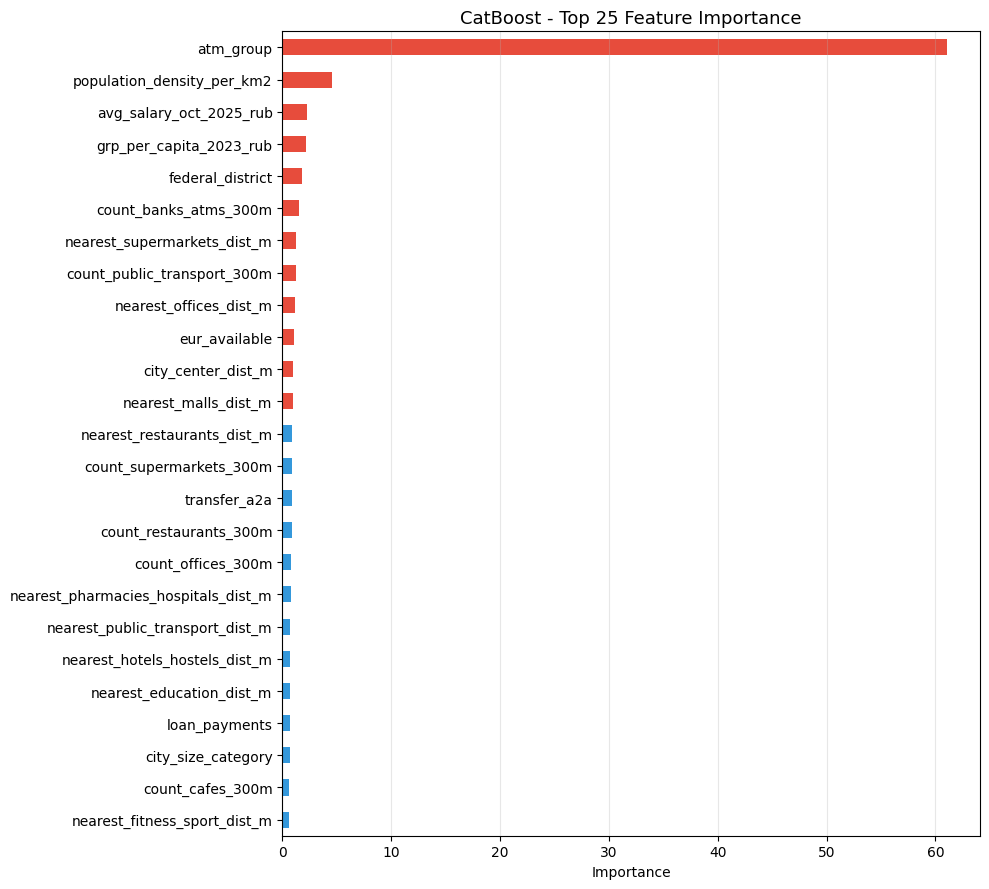


Top 15 features:
atm_group                     61.0362
population_density_per_km2     4.5514
avg_salary_oct_2025_rub        2.2447
grp_per_capita_2023_rub        2.1812
federal_district               1.8383
count_banks_atms_300m          1.5014
nearest_supermarkets_dist_m    1.2896
count_public_transport_300m    1.2467
nearest_offices_dist_m         1.1340
eur_available                  1.0627
city_center_dist_m             1.0244
nearest_malls_dist_m           0.9616
nearest_restaurants_dist_m     0.8937
count_supermarkets_300m        0.8903
transfer_a2a                   0.8541


In [11]:
feat_imp = pd.Series(
    cb_final.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top25 = feat_imp.head(25).iloc[::-1]
median_imp = top25.median()
colors = ['#e74c3c' if v > median_imp else '#3498db' for v in top25.values]
top25.plot.barh(ax=ax, color=colors)
ax.set_title('CatBoost - Top 25 Feature Importance', fontsize=13)
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(feat_imp.head(15).to_string())

## 11. Итоги

In [ ]:
summary = pd.DataFrame([
    {'Эксперимент': 'Baseline', 'RMSE': rmse_base,  'MAE': mae_base,  'R2': r2_base,
     'Fit time, s': base_m['Fit time, s'],  'Predict time, s': base_m['Predict time, s']},
    {'Эксперимент': 'Optuna',   'RMSE': rmse_final, 'MAE': mae_final, 'R2': r2_final,
     'Fit time, s': final_m['Fit time, s'], 'Predict time, s': final_m['Predict time, s']},
]).set_index('Эксперимент')

display(
    summary.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
             'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R2'])
)

,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Эксперимент,,,,,
Baseline,0.0455,0.0365,0.7223,14.01,0.0034
Optuna,0.0453,0.0362,0.7249,17.62,0.0043



RMSE baseline: 0.0455  ->  final: 0.0453  (delta: +0.0002)
R2   baseline: 0.7223  ->  final: 0.7249


## 12. Сохранение модели

In [13]:
cb_save.save_model(str(MODEL_SAVE_PATH))
print(f'Model saved -> {MODEL_SAVE_PATH}')

Model saved -> ..\models\catboost_best.cbm
